In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from mlxtend.plotting import plot_decision_regions

In [ ]:
df = pd.DataFrame()


In [3]:
df['x1'] = [1, 2, 3, 4, 5, 6, 6, 7, 9, 9]
df['x2'] = [5, 3, 6, 8, 1, 9, 5, 8, 9, 2]

df['label'] = [1, 1, 0, 1, 0, 1, 0, 1, 0, 0]

In [ ]:
df


,x1,x2,label
0,1,5,1
1,2,3,1
2,3,6,0
3,4,8,1
4,5,1,0
5,6,9,1
6,6,5,0
7,7,8,1
8,9,9,0
9,9,2,0


<Axes: xlabel='x1', ylabel='x2'>

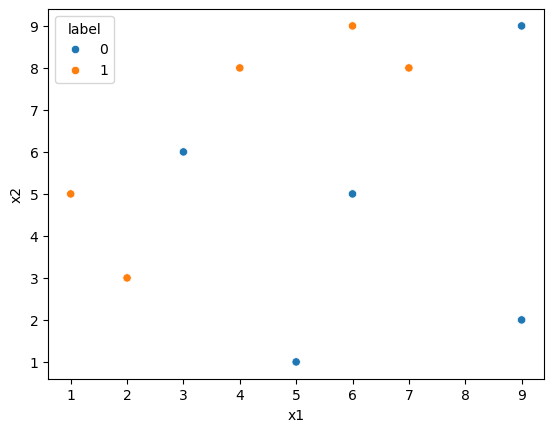

In [5]:
import seaborn as sns
sns.scatterplot(data=df, x='x1', y='x2', hue='label')

In [6]:
df['weights'] = 1 / len(df)

In [7]:
df


,x1,x2,label,weights
0,1,5,1,0.1
1,2,3,1,0.1
2,3,6,0,0.1
3,4,8,1,0.1
4,5,1,0,0.1
5,6,9,1,0.1
6,6,5,0,0.1
7,7,8,1,0.1
8,9,9,0,0.1
9,9,2,0,0.1


In [8]:
from sklearn.tree import DecisionTreeClassifier
dt1 = DecisionTreeClassifier(max_depth=1)

In [9]:
x = df.iloc[:, 0:2].values
y = df.iloc[:, 2].values

In [10]:
dt1.fit(x, y, sample_weight=df['weights'])

,criterion,'gini'
,splitter,'best'
,max_depth,1
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


[Text(0.5, 0.75, 'x[0] <= 2.5\ngini = 0.5\nsamples = 10\nvalue = [0.5, 0.5]'),
 Text(0.25, 0.25, 'gini = 0.0\nsamples = 2\nvalue = [0.0, 0.2]'),
 Text(0.375, 0.5, 'True  '),
 Text(0.75, 0.25, 'gini = 0.469\nsamples = 8\nvalue = [0.5, 0.3]'),
 Text(0.625, 0.5, '  False')]

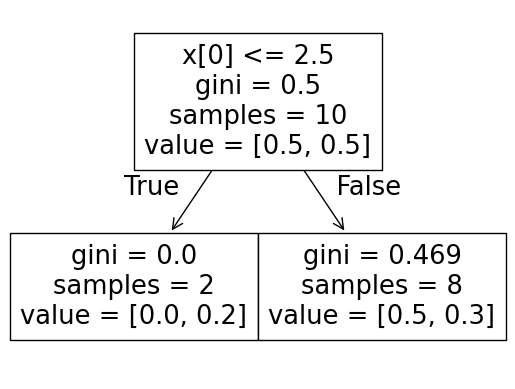

In [11]:
from sklearn.tree import plot_tree
plot_tree(dt1)

<Axes: >

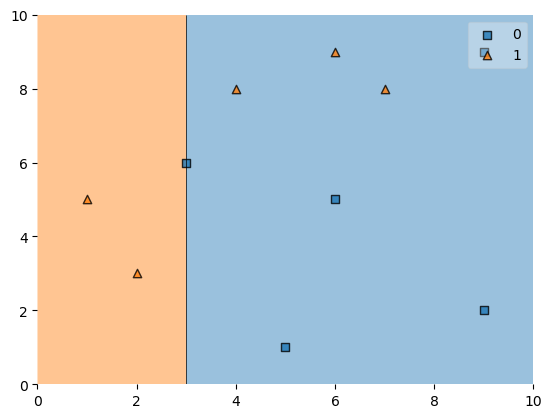

In [12]:
plot_decision_regions(x, y, clf=dt1)

In [13]:
df['y_pred'] = dt1.predict(x)

In [14]:
df

,x1,x2,label,weights,y_pred
0,1,5,1,0.1,1
1,2,3,1,0.1,1
2,3,6,0,0.1,0
3,4,8,1,0.1,0
4,5,1,0,0.1,0
5,6,9,1,0.1,0
6,6,5,0,0.1,0
7,7,8,1,0.1,0
8,9,9,0,0.1,0
9,9,2,0,0.1,0


In [15]:
def calculate_model_weight(error):
    return 0.5 * np.log((1 - error) / error)

In [ ]:
# step 3 - calculate model weight
alpha1 = calculate_model_weight(0.3)
alpha1

np.float64(0.42364893019360184)

In [17]:
# step 4 - update weights
def update_weights(row, alpha = .4236):
    if row['label'] == row['y_pred']:
        return row['weights'] * np.exp(-alpha)
    else:
        return row['weights'] * np.exp(alpha)

In [18]:
df['updated_weights'] = df.apply(update_weights, axis=1)

In [19]:
df


,x1,x2,label,weights,y_pred,updated_weights
0,1,5,1,0.1,1,0.065469
1,2,3,1,0.1,1,0.065469
2,3,6,0,0.1,0,0.065469
3,4,8,1,0.1,0,0.152745
4,5,1,0,0.1,0,0.065469
5,6,9,1,0.1,0,0.152745
6,6,5,0,0.1,0,0.065469
7,7,8,1,0.1,0,0.152745
8,9,9,0,0.1,0,0.065469
9,9,2,0,0.1,0,0.065469


In [20]:
df['normalized_weights'] = df['updated_weights'] / df['updated_weights'].sum()

In [21]:
df['updated_weights'].sum()

np.float64(0.9165151400883117)

In [22]:
df['normalized_weights'].sum()

np.float64(1.0)

In [23]:
df['cumsum_upper'] = np.cumsum(df['normalized_weights'])
df['cumsum_lower'] = df['cumsum_upper'] - df['normalized_weights']

In [24]:
df

,x1,x2,label,weights,y_pred,updated_weights,normalized_weights,cumsum_upper,cumsum_lower
0,1,5,1,0.1,1,0.065469,0.071432,0.071432,0.000000
1,2,3,1,0.1,1,0.065469,0.071432,0.142864,0.071432
2,3,6,0,0.1,0,0.065469,0.071432,0.214296,0.142864
3,4,8,1,0.1,0,0.152745,0.166659,0.380955,0.214296
4,5,1,0,0.1,0,0.065469,0.071432,0.452387,0.380955
5,6,9,1,0.1,0,0.152745,0.166659,0.619045,0.452387
6,6,5,0,0.1,0,0.065469,0.071432,0.690477,0.619045
7,7,8,1,0.1,0,0.152745,0.166659,0.857136,0.690477
8,9,9,0,0.1,0,0.065469,0.071432,0.928568,0.857136
9,9,2,0,0.1,0,0.065469,0.071432,1.000000,0.928568


In [25]:
def create_new_dataset(df):
    indices = []
    for i in range(len(df)):
        a = np.random.random()
        for idx, row in df.iterrows():
            if row['cumsum_lower'] <= a < row['cumsum_upper']:
                indices.append(idx)
                break
    return indices

In [26]:
idx_values = create_new_dataset(df)
idx_values

[7, 7, 5, 3, 5, 2, 1, 2, 9, 7]